# Polynomial Regression

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [ ]:
df = pd.read_csv('Position_Salaries.csv')
x = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values

## Training the Polynomial Regression model on the whole dataset

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
pr = PolynomialFeatures(degree=5)
x_poly = pr.fit_transform(x)
plr = LinearRegression()
plr.fit(x_poly, y)

LinearRegression()

## Visualising the Polynomial Regression results

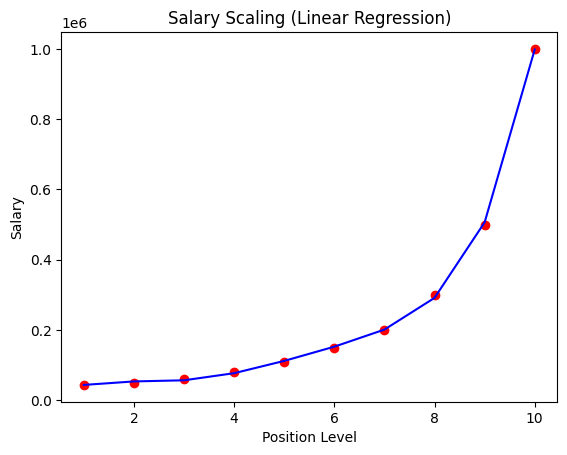

In [ ]:
plt.scatter(x, y, color='red')
plt.plot(x, plr.predict(x_poly), color='blue')
plt.title('Salary Scaling (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

## Testing for overfitting with Leave-One-Out Cross-Validation

In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
loo = LeaveOneOut()

def loocv_mse(degree):
  pr = PolynomialFeatures(degree=degree)
  x_poly = pr.fit_transform(x)
  model = LinearRegression()
  mse_scores = -cross_val_score(model, x_poly, y, cv=loo, scoring='neg_mean_squared_error')
  return np.mean(mse_scores)

mse_4 = loocv_mse(4)
mse_5 = loocv_mse(5)
mse_6 = loocv_mse(6)

print(f"MSE for degree 4: {mse_4}")
print(f"MSE for degree 5: {mse_5}")
print(f"MSE for degree 6: {mse_6}")

# 5 degrees is the best fit


MSE for degree 4: 5451200363.390267
MSE for degree 5: 1474751107.0300758
MSE for degree 6: 1512546790.6482723


## Predicting a new result with Polynomial Regression

In [ ]:
level = 10
new_employee = np.array([[level]])
# For predictions, make sure to ONLY transform, don't re-fit new data into trained model
new_employee_poly = pr.transform(new_employee)
predicted_salary = plr.predict(new_employee_poly)
print(f"Predicted salary for a level ${level} employee: ${predicted_salary[0]:.2f}")

Predicted salary for a level $10 employee: $998377.62


## Saving the model

In [7]:
import joblib

joblib.dump(pr, 'poly_transformer.pkl')
joblib.dump(plr, 'salary_model.pkl')


['salary_model.pkl']